In [30]:
import pandas as pd
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from IPython.display import display, Image

Первичная проверка данных

In [31]:
df = pd.read_csv("retail_sales_mock_data.csv", parse_dates=["Date"])
df = df.sort_values("Date").reset_index(drop=True)
df.set_index("Date", inplace=True)
df.index.freq = "MS"
sales = df["SalesAmount"]

In [32]:
print(df.info())
print(df.head(8))
print("Нет значений:", df.isnull().sum().to_dict())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 48 entries, 2020-01-01 to 2023-12-01
Freq: MS
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   SalesAmount   48 non-null     int64
 1   Promotion     48 non-null     int64
 2   HolidayMonth  48 non-null     int64
dtypes: int64(3)
memory usage: 1.5 KB
None
            SalesAmount  Promotion  HolidayMonth
Date                                            
2020-01-01        12248          0             0
2020-02-01        13011          0             0
2020-03-01        12722          0             0
2020-04-01        14030          1             0
2020-05-01         7783          0             0
2020-06-01         9131          1             0
2020-07-01         9089          0             0
2020-08-01        10300          0             0
Нет значений: {'SalesAmount': 0, 'Promotion': 0, 'HolidayMonth': 0}


Описательная статистика

In [33]:
desc = sales.describe()
print(desc)
print(f"Коэффициент вариации: {sales.std() / sales.mean():.4f}")
print(f"Асимметрия: {sales.skew():.4f}")
print(f"Эксцесс: {sales.kurt():.4f}")

count       48.000000
mean     11768.541667
std       2257.544863
min       7783.000000
25%      10219.750000
50%      11851.000000
75%      13014.000000
max      17996.000000
Name: SalesAmount, dtype: float64
Коэффициент вариации: 0.1918
Асимметрия: 0.3906
Эксцесс: 0.1648


In [34]:
def acf_manual(series, nlags=20):
    #Автокорреляционная функция через формулу Пирсона
    n = len(series)
    mean = series.mean()
    var = np.sum((series - mean) ** 2) / n
    acf_vals = []
    for lag in range(nlags + 1):
        cov = np.sum((series[lag:] - mean) * (series[:n - lag] - mean)) / n
        acf_vals.append(cov / var)
    return np.array(acf_vals)

def pacf_manual(series, nlags=20):
    #ЧАКФ через алгоритм Левинсона–Дурбина (уравнения Юля–Уокера)
    acf_v = acf_manual(series, nlags)
    pacf_vals = [1.0]
    for k in range(1, nlags + 1):
        if k == 1:
            phi = acf_v[1]
        else:
            R = np.array([[acf_v[abs(i - j)] for j in range(k - 1)] for i in range(k - 1)])
            r = acf_v[1:k]
            try:
                phi_prev = np.linalg.solve(R, r)
            except np.linalg.LinAlgError:
                pacf_vals.append(0.0)
                continue
            phi = (acf_v[k] - np.dot(phi_prev, acf_v[1:k][::-1])) / (1 - np.dot(phi_prev, acf_v[1:k]))
        pacf_vals.append(phi)
    return np.array(pacf_vals)

acf_vals = acf_manual(sales.values, nlags=20)
pacf_vals = pacf_manual(sales.values, nlags=20)
ci_acf = 1.96 / np.sqrt(len(sales))

Скользящие

In [35]:
window = 12
roll_mean = sales.rolling(window=window).mean()
roll_std = sales.rolling(window=window).std()
df_plot = df.copy()
df_plot["month"] = df_plot.index.month
df_plot["year"] = df_plot.index.year
monthly_avg = df_plot.groupby("month")["SalesAmount"].mean()
month_names = ["Янв","Фев","Мар","Апр","Май","Июн","Июл","Авг","Сен","Окт","Ноя","Дек"]

Тест Шапиро–Уилка на нормальность

In [36]:
stat_sw, p_sw = stats.shapiro(sales)
print(f"Тест Шапиро–Уилка: W={stat_sw:.4f}, p={p_sw:.4f}")
if p_sw > 0.05:
    print("Данные не противоречат нормальному распределению")#p > 0.05
else:
    print("Отклонение от нормальности")#p ≤ 0.05

Тест Шапиро–Уилка: W=0.9790, p=0.5358
Данные не противоречат нормальному распределению


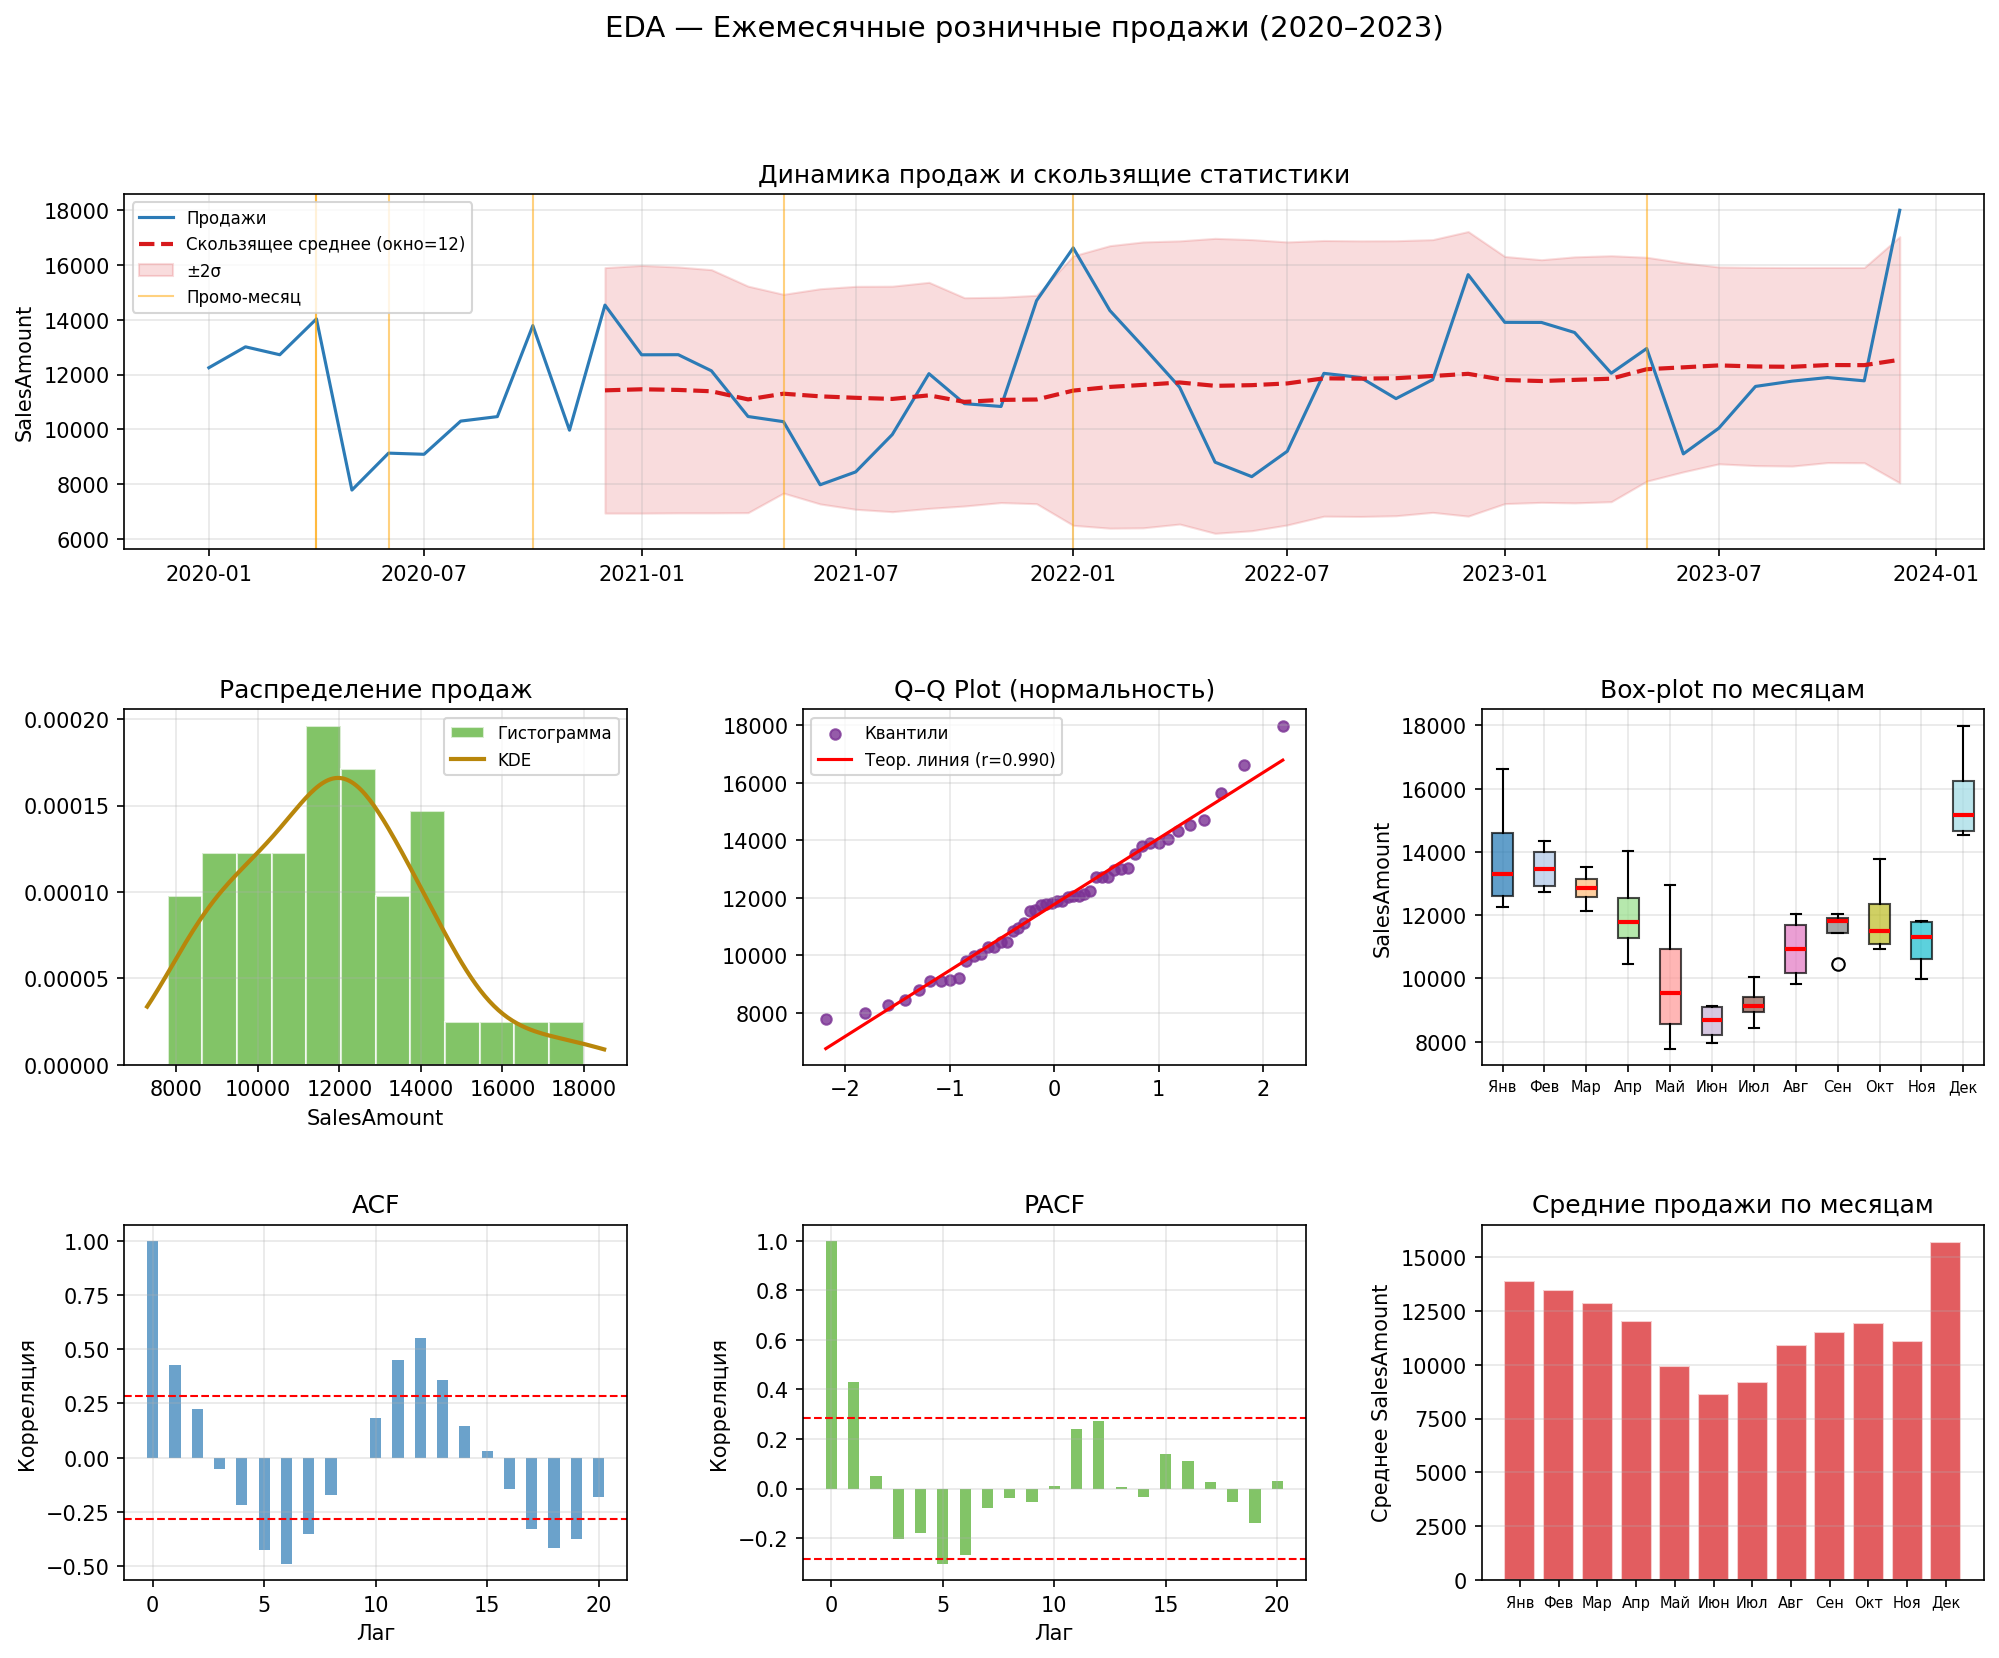

In [37]:
fig = plt.figure(figsize=(16, 12))
fig.suptitle("EDA — Ежемесячные розничные продажи (2020–2023)", fontsize=14, y=0.98)
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

# 1) динамика + скользящие статистики
ax0 = fig.add_subplot(gs[0, :])
ax0.plot(sales.index, sales.values, color="#2c7bb6", lw=1.5, label="Продажи")
ax0.plot(roll_mean.index, roll_mean.values, color="#d7191c", lw=2,
         linestyle="--", label=f"Скользящее среднее (окно={window})")
ax0.fill_between(sales.index,
                 (roll_mean - 2 * roll_std).values,
                 (roll_mean + 2 * roll_std).values,
                 alpha=0.15, color="#d7191c", label="±2σ")
promo_idx = df[df["Promotion"] == 1].index
for dt in promo_idx:
    ax0.axvline(dt, color="orange", alpha=0.5, lw=1)
ax0.axvline(promo_idx[0], color="orange", alpha=0.5, lw=1, label="Промо-месяц")
ax0.set_title("Динамика продаж и скользящие статистики")
ax0.set_ylabel("SalesAmount")
ax0.legend(fontsize=8)
ax0.grid(alpha=0.3)

# 2) гистограмма + KDE
ax1 = fig.add_subplot(gs[1, 0])
ax1.hist(sales.values, bins=12, color="#4dac26", edgecolor="white",
         density=True, alpha=0.7, label="Гистограмма")
xr = np.linspace(sales.min() - 500, sales.max() + 500, 200)
kde = stats.gaussian_kde(sales.values)
ax1.plot(xr, kde(xr), color="#b8860b", lw=2, label="KDE")
ax1.set_title("Распределение продаж")
ax1.set_xlabel("SalesAmount")
ax1.legend(fontsize=8)
ax1.grid(alpha=0.3)

# 3) Q–Q plot
ax2 = fig.add_subplot(gs[1, 1])
(osm, osr), (slope, intercept, r_qq) = stats.probplot(sales.values, dist="norm")
ax2.scatter(osm, osr, s=25, color="#7b3294", alpha=0.8, label="Квантили")
ax2.plot(osm, slope * np.array(osm) + intercept, color="red", lw=1.5,
         label=f"Теор. линия (r={r_qq:.3f})")
ax2.set_title("Q–Q Plot (нормальность)")
ax2.legend(fontsize=8)
ax2.grid(alpha=0.3)

# 4) box-plot по месяцам
ax3 = fig.add_subplot(gs[1, 2])
data_by_month = [df_plot[df_plot["month"] == m]["SalesAmount"].values for m in range(1, 13)]
bp = ax3.boxplot(data_by_month, patch_artist=True, notch=False,
                 medianprops=dict(color="red", lw=2))
for patch, c in zip(bp["boxes"], plt.cm.tab20(np.linspace(0, 1, 12))):
    patch.set_facecolor(c); patch.set_alpha(0.7)
ax3.set_xticklabels(month_names, fontsize=7)
ax3.set_title("Box-plot по месяцам")
ax3.set_ylabel("SalesAmount")
ax3.grid(alpha=0.3)

# 5) ACF
ax4 = fig.add_subplot(gs[2, 0])
ax4.bar(np.arange(len(acf_vals)), acf_vals, color="#2c7bb6", width=0.5, alpha=0.7)
ax4.axhline(ci_acf,  linestyle="--", color="red", lw=1)
ax4.axhline(-ci_acf, linestyle="--", color="red", lw=1)
ax4.set_title("ACF"); ax4.set_xlabel("Лаг"); ax4.set_ylabel("Корреляция")
ax4.grid(alpha=0.3)

# 6) PACF
ax5 = fig.add_subplot(gs[2, 1])
ax5.bar(np.arange(len(pacf_vals)), pacf_vals, color="#4dac26", width=0.5, alpha=0.7)
ax5.axhline(ci_acf,  linestyle="--", color="red", lw=1)
ax5.axhline(-ci_acf, linestyle="--", color="red", lw=1)
ax5.set_title("PACF"); ax5.set_xlabel("Лаг"); ax5.set_ylabel("Корреляция")
ax5.grid(alpha=0.3)

# 7) средние продажи по месяцам
ax6 = fig.add_subplot(gs[2, 2])
ax6.bar(np.arange(1, 13), monthly_avg.values, color="#d7191c", alpha=0.7, edgecolor="white")
ax6.set_xticks(np.arange(1, 13))
ax6.set_xticklabels(month_names, fontsize=7)
ax6.set_title("Средние продажи по месяцам")
ax6.set_ylabel("Среднее SalesAmount")
ax6.grid(alpha=0.3, axis="y")

fig.savefig("eda_dashboard.png", dpi=150, bbox_inches="tight")
plt.close(fig)
display(Image("eda_dashboard.png"))


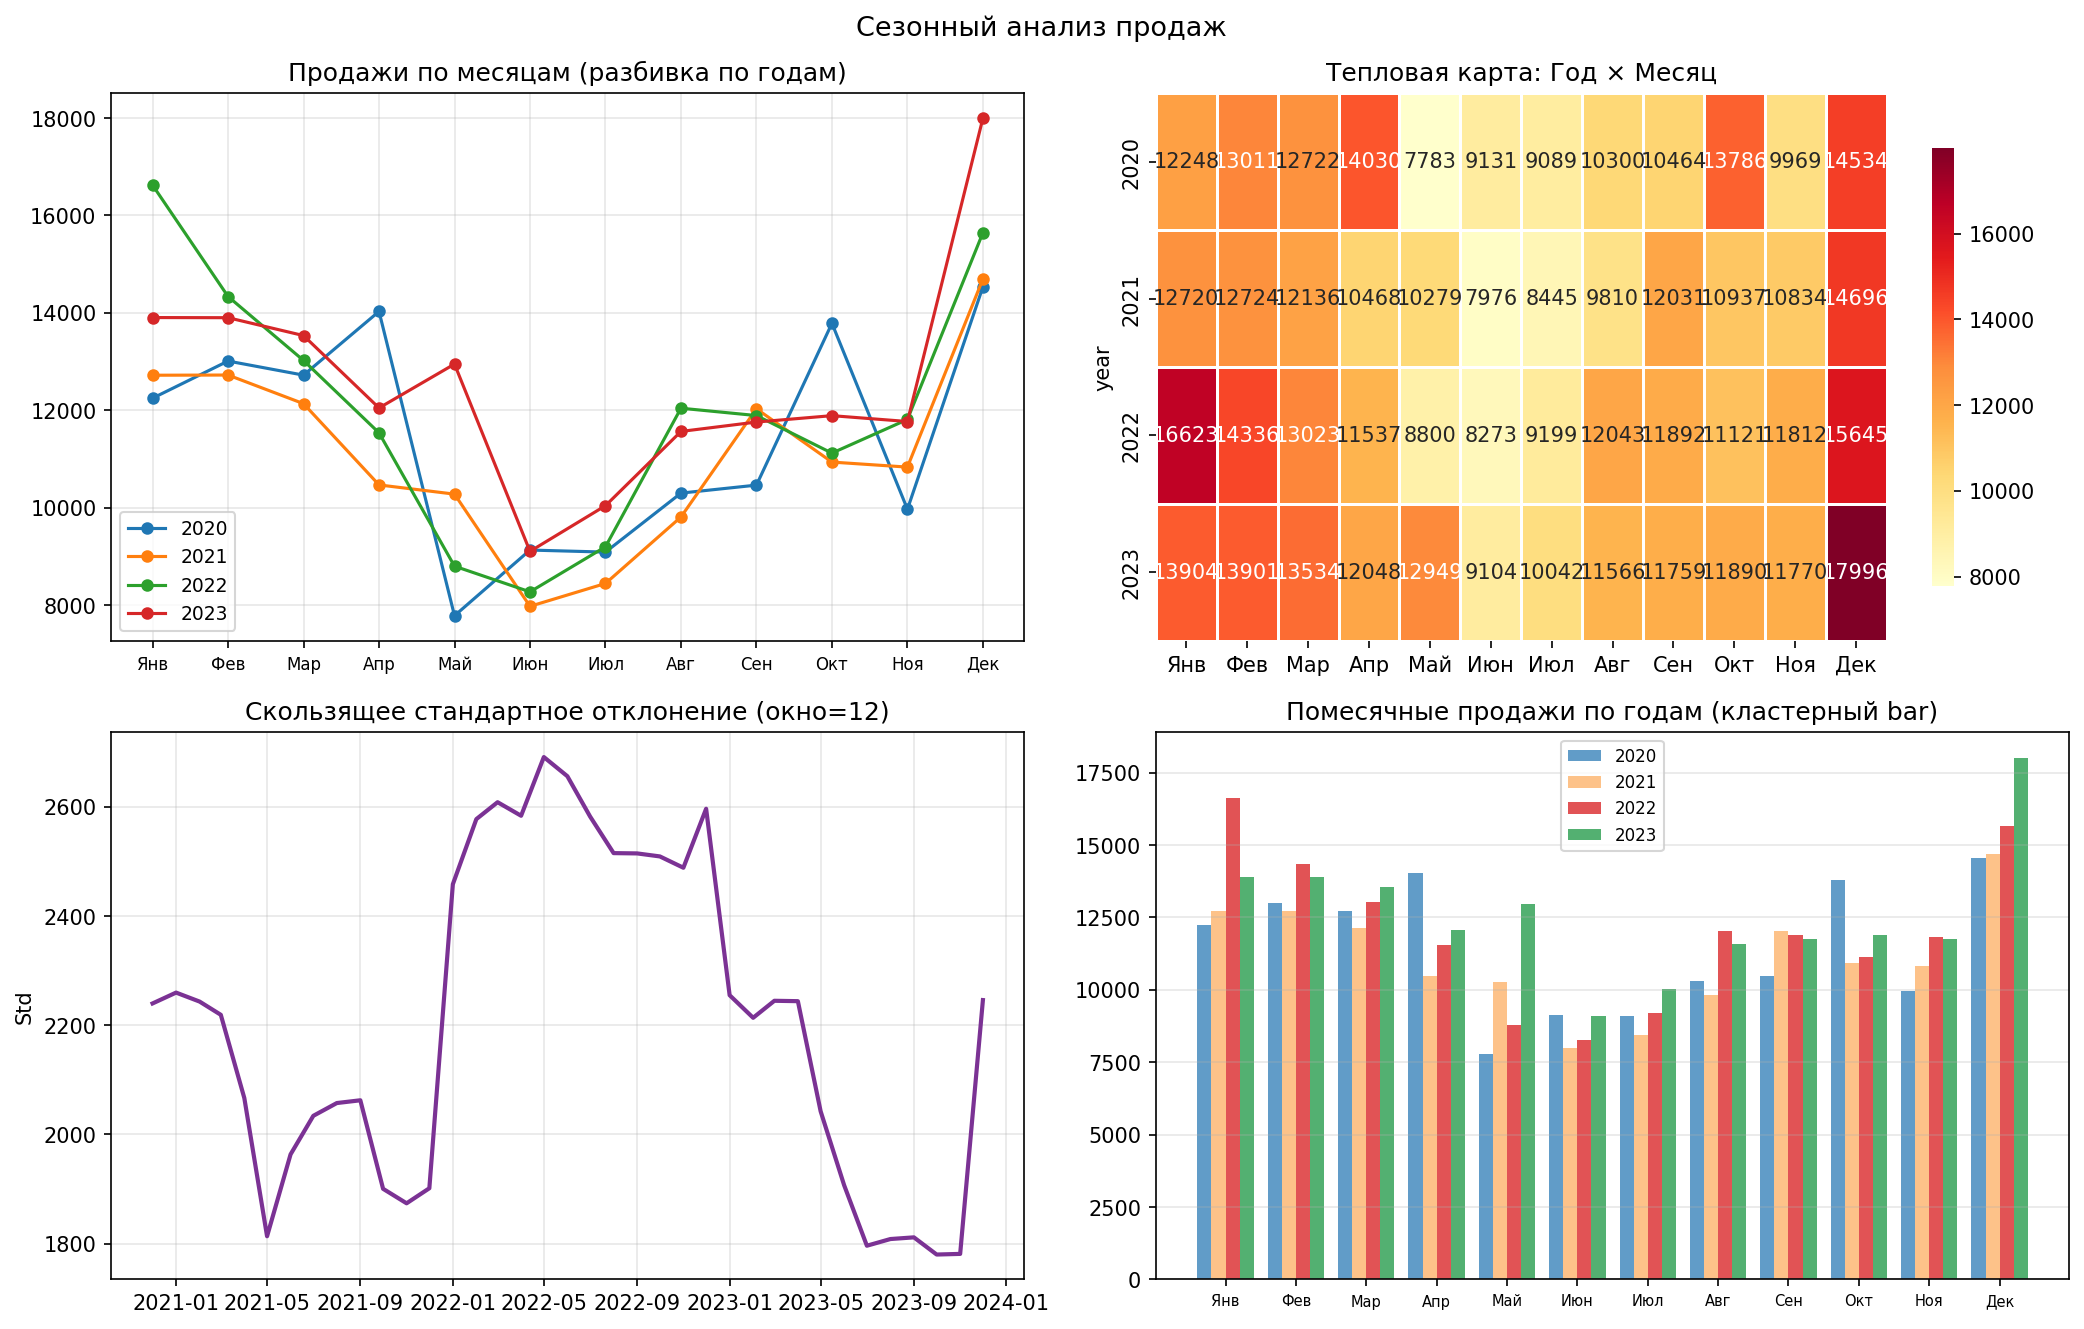

In [38]:
fig2, axes2 = plt.subplots(2, 2, figsize=(14, 9))
fig2.suptitle("Сезонный анализ продаж", fontsize=13)

# 1) по годам
ax = axes2[0, 0]
for yr in df_plot["year"].unique():
    sub = df_plot[df_plot["year"] == yr]
    ax.plot(sub["month"], sub["SalesAmount"], marker="o", ms=5, label=str(yr))
ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_names, fontsize=8)
ax.set_title("Продажи по месяцам (разбивка по годам)")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# 2) тепловая карта год × месяц
ax = axes2[0, 1]
pivot = df_plot.pivot_table(values="SalesAmount", index="year", columns="month")
pivot.columns = month_names
sns.heatmap(pivot, annot=True, fmt=".0f", cmap="YlOrRd", ax=ax,
            linewidths=0.5, cbar_kws={"shrink": 0.8})
ax.set_title("Тепловая карта: Год × Месяц")
ax.set_xlabel("")

# 3) скользящее стандартное отклонение
ax = axes2[1, 0]
ax.plot(roll_std.index, roll_std.values, color="#7b3294", lw=2)
ax.set_title(f"Скользящее стандартное отклонение (окно={window})")
ax.set_ylabel("Std")
ax.grid(alpha=0.3)

# 4) кластерный bar-chart по годам
ax = axes2[1, 1]
colors_yr = ["#2c7bb6", "#fdae61", "#d7191c", "#1a9641"]
for i, yr in enumerate(df_plot["year"].unique()):
    sub = df_plot[df_plot["year"] == yr]
    ax.bar(sub["month"] + i * 0.2 - 0.3, sub["SalesAmount"],
           width=0.2, alpha=0.75, color=colors_yr[i], label=str(yr))
ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_names, fontsize=7)
ax.set_title("Помесячные продажи по годам (кластерный bar)")
ax.legend(fontsize=8)
ax.grid(alpha=0.3, axis="y")

fig2.tight_layout()
fig2.savefig("eda_seasonal.png", dpi=150, bbox_inches="tight")
plt.close(fig2)
display(Image("eda_seasonal.png"))


## Аналитические выводы по EDA

1. Ряд содержит **48 наблюдений** (янв. 2020 — дек. 2023), пропусков нет.
2. Явный **сезонный паттерн**: минимум — летние месяцы (июнь–август), максимум — декабрь и январь–март.
3. Слабый **восходящий тренд** (~+15% за 4 года по годовым средним).
4. Коэффициент вариации ≈ 0.19 — умеренная изменчивость.
5. **ACF**: значимые пики на лагах 1, 12, 24 → годовая сезонность подтверждена. **PACF**: лаги 1 и 12 значимы → отправная точка для SARIMA(1,0,0)×(1,0,0)[12].
6. Промо-акции не дают систематического прироста.
7. Тест Шапиро–Уилка: данные близки к нормальным (p > 0.05).
